In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

In [28]:
df = pd.read_csv("../data/preprocessed_application_train.csv")

# 1. Feature engineering from main table

In [29]:
df['CREDIT_INCOME_RATIO'] = df['AMT_CREDIT'] / df['AMT_INCOME_TOTAL'].clip(lower=1)
df['ANNUITY_INCOME_RATIO'] = df['AMT_ANNUITY'] /df['AMT_INCOME_TOTAL'].clip(lower=1)
df['CREDIT_TERM'] = df['AMT_ANNUITY'] / df['AMT_CREDIT'].clip(lower=1)
df['DAYS_EMPLOYED_RATIO'] = df['DAYS_EMPLOYED'] /df['DAYS_BIRTH']
df['INCOME_PER_PERSON'] = df['AMT_INCOME_TOTAL'] / df['CNT_FAM_MEMBERS'].clip(lower=1)

ext_cols = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']
df['EXT_SOURCE_MEAN'] = df[ext_cols].mean(axis=1)
df['EXT_SOURCE_STD'] = df[ext_cols].std(axis=1)

df['AGE'] = (-df['DAYS_BIRTH']) / 365
df['AGE_BUCKET'] = pd.cut(df['AGE'], bins=[20, 30, 40, 50, 60, 70, 100],  labels=['20-30', '30-40', '40-50', '50-60', '60-70', '70+'])


In [30]:
engineered_feats = [
    'CREDIT_INCOME_RATIO',
    'ANNUITY_INCOME_RATIO',
    'CREDIT_TERM',
    'DAYS_EMPLOYED_RATIO',
    'INCOME_PER_PERSON',
    'EXT_SOURCE_MEAN',
    'EXT_SOURCE_STD'
]

corrs = df[engineered_feats].corrwith(df['TARGET']).abs().sort_values(ascending=False)
print(corrs)

EXT_SOURCE_MEAN         0.220840
EXT_SOURCE_STD          0.078034
DAYS_EMPLOYED_RATIO     0.049603
ANNUITY_INCOME_RATIO    0.014268
CREDIT_TERM             0.012698
CREDIT_INCOME_RATIO     0.007727
INCOME_PER_PERSON       0.006573
dtype: float64


In [31]:
bureau_df = pd.read_csv("../data/bureau.csv")

print(f'Shape: {bureau_df.shape}')
print(f'\nColumn names: {bureau_df.columns.tolist()}')
print(f'\nData types: {bureau_df.dtypes}')

Shape: (1716428, 17)

Column names: ['SK_ID_CURR', 'SK_ID_BUREAU', 'CREDIT_ACTIVE', 'CREDIT_CURRENCY', 'DAYS_CREDIT', 'CREDIT_DAY_OVERDUE', 'DAYS_CREDIT_ENDDATE', 'DAYS_ENDDATE_FACT', 'AMT_CREDIT_MAX_OVERDUE', 'CNT_CREDIT_PROLONG', 'AMT_CREDIT_SUM', 'AMT_CREDIT_SUM_DEBT', 'AMT_CREDIT_SUM_LIMIT', 'AMT_CREDIT_SUM_OVERDUE', 'CREDIT_TYPE', 'DAYS_CREDIT_UPDATE', 'AMT_ANNUITY']

Data types: SK_ID_CURR                  int64
SK_ID_BUREAU                int64
CREDIT_ACTIVE              object
CREDIT_CURRENCY            object
DAYS_CREDIT                 int64
CREDIT_DAY_OVERDUE          int64
DAYS_CREDIT_ENDDATE       float64
DAYS_ENDDATE_FACT         float64
AMT_CREDIT_MAX_OVERDUE    float64
CNT_CREDIT_PROLONG          int64
AMT_CREDIT_SUM            float64
AMT_CREDIT_SUM_DEBT       float64
AMT_CREDIT_SUM_LIMIT      float64
AMT_CREDIT_SUM_OVERDUE    float64
CREDIT_TYPE                object
DAYS_CREDIT_UPDATE          int64
AMT_ANNUITY               float64
dtype: object


In [32]:
bureau_features = bureau_df.groupby('SK_ID_CURR').agg(
    BUREAU_RECORD_COUNT=('SK_ID_BUREAU', 'count'),
    ACTIVE_CREDIT_COUNT=('CREDIT_ACTIVE', lambda x: (x=='Active').sum()),
    MEAN_DAYS_CREDIT=('DAYS_CREDIT', 'mean'),
    MAX_CREDIT_OVERDUE=('AMT_CREDIT_SUM_OVERDUE', 'max')  
).reset_index()

bureau_features

,SK_ID_CURR,BUREAU_RECORD_COUNT,ACTIVE_CREDIT_COUNT,MEAN_DAYS_CREDIT,MAX_CREDIT_OVERDUE
0,100001,7,3,-735.000000,0.0
1,100002,8,2,-874.000000,0.0
2,100003,4,1,-1400.750000,0.0
3,100004,2,0,-867.000000,0.0
4,100005,3,2,-190.666667,0.0
...,...,...,...,...,...
305806,456249,13,2,-1667.076923,0.0
305807,456250,3,2,-862.000000,0.0
305808,456253,4,2,-867.500000,0.0
305809,456254,1,0,-1104.000000,0.0


In [33]:
df = df.merge(bureau_features,on='SK_ID_CURR',how='left')

In [34]:
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,DAYS_EMPLOYED_RATIO,INCOME_PER_PERSON,EXT_SOURCE_MEAN,EXT_SOURCE_STD,AGE,AGE_BUCKET,BUREAU_RECORD_COUNT,ACTIVE_CREDIT_COUNT,MEAN_DAYS_CREDIT,MAX_CREDIT_OVERDUE
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0.067329,202500.0,0.161787,0.092026,25.920548,20-30,8.0,2.0,-874.00,0.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0.070862,135000.0,0.489596,0.160443,45.931507,40-50,4.0,1.0,-1400.75,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0.011814,67500.0,0.597159,0.117353,52.180822,50-60,2.0,0.0,-867.00,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0.159905,67500.0,0.563905,0.076359,52.068493,50-60,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0.152418,121500.0,0.454671,0.115191,54.608219,50-60,1.0,0.0,-1149.00,0.0


# 2. Encoding
**Ordinal for NAME_EDUCATION_TYPE (ordered), one-hot for others with <10 categories. Drop high-cardinality categoricals (>50 categories) or use frequency encoding.**

In [35]:
df['NAME_EDUCATION_TYPE'].unique().tolist()

['Secondary / secondary special',
 'Higher education',
 'Incomplete higher',
 'Lower secondary',
 'Academic degree']

### 1. Identify the catogorical columns

In [36]:
cat_cols = df.select_dtypes(include='object').columns

print(f'Number of categorical columns: {len(cat_cols)}')
cat_cols.tolist()

Number of categorical columns: 16


['NAME_CONTRACT_TYPE',
 'CODE_GENDER',
 'FLAG_OWN_CAR',
 'FLAG_OWN_REALTY',
 'NAME_TYPE_SUITE',
 'NAME_INCOME_TYPE',
 'NAME_EDUCATION_TYPE',
 'NAME_FAMILY_STATUS',
 'NAME_HOUSING_TYPE',
 'OCCUPATION_TYPE',
 'WEEKDAY_APPR_PROCESS_START',
 'ORGANIZATION_TYPE',
 'FONDKAPREMONT_MODE',
 'HOUSETYPE_MODE',
 'WALLSMATERIAL_MODE',
 'EMERGENCYSTATE_MODE']

### 2. Ordinal encoding for 'NAME_EDUCATION_TYPE'

In [37]:
education_order = {
    'Lower secondary': 0,
    'Secondary / secondary special': 1,
    'Incomplete higher': 2,
    'Higher education': 3,
    'Academic degree': 4
}

df['NAME_EDUCATION_TYPE'] = df['NAME_EDUCATION_TYPE'].map(education_order)
df['NAME_EDUCATION_TYPE']

0         1
1         3
2         1
3         1
4         1
         ..
307506    1
307507    1
307508    3
307509    1
307510    3
Name: NAME_EDUCATION_TYPE, Length: 307511, dtype: int64

### 3. One-hot encoding for unordered(<10 categories)

In [38]:
low_card_cols = [
    col for col in cat_cols
    if col != 'NAME_EDUCATION_TYPE'
    and df[col].nunique() < 10
]

df = pd.get_dummies(df, columns=low_card_cols, drop_first=True)

In [39]:
df.head()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_EDUCATION_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,...,FONDKAPREMONT_MODE_reg oper spec account,HOUSETYPE_MODE_specific housing,HOUSETYPE_MODE_terraced house,WALLSMATERIAL_MODE_Mixed,WALLSMATERIAL_MODE_Monolithic,WALLSMATERIAL_MODE_Others,WALLSMATERIAL_MODE_Panel,"WALLSMATERIAL_MODE_Stone, brick",WALLSMATERIAL_MODE_Wooden,EMERGENCYSTATE_MODE_Yes
0,100002,1,0,202500.0,406597.5,24700.5,351000.0,1,0.018801,-9461,...,False,False,False,False,False,False,False,True,False,False
1,100003,0,0,270000.0,1293502.5,35698.5,1129500.0,3,0.003541,-16765,...,False,False,False,False,False,False,False,False,False,False
2,100004,0,0,67500.0,135000.0,6750.0,135000.0,1,0.010032,-19046,...,False,False,False,False,False,False,True,False,False,False
3,100006,0,0,135000.0,312682.5,29686.5,297000.0,1,0.008019,-19005,...,False,False,False,False,False,False,True,False,False,False
4,100007,0,0,121500.0,513000.0,21865.5,513000.0,1,0.028663,-19932,...,False,False,False,False,False,False,True,False,False,False


### 4. Frequency encoding for high-cardinality categoricals (>50 categories)

In [42]:
cat_cols = df.select_dtypes(include="object").columns

high_card_cols = [
    col for col in cat_cols
    if df[col].nunique() > 50
]

print(high_card_cols)

['ORGANIZATION_TYPE']


In [44]:
for col in high_card_cols:
    freq = df[col].value_counts(normalize=True)
    df[col + '_freq'] = df[col].map(freq)
    
df.drop(columns=high_card_cols, inplace=True)

In [47]:
print(df.shape)
print(df.select_dtypes(include='object').columns.tolist())

(307511, 226)
['OCCUPATION_TYPE']


In [48]:
freq = df['OCCUPATION_TYPE'].value_counts(normalize=True)

df['OCCUPATION_TYPE_freq'] = (
    df['OCCUPATION_TYPE']
    .map(freq)
)

df.drop(columns=['OCCUPATION_TYPE'], inplace=True)

In [50]:
print(df.shape)
print(df.select_dtypes(include='object').columns.tolist())

(307511, 226)
[]


In [51]:
df.to_csv("../data/preprocessed_train.csv", index=False)

# Customer Segmentation

In [53]:
df = pd.read_csv('../data/preprocessed_train.csv')

print(df.shape)
df.head()

(307511, 226)


,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_EDUCATION_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,...,HOUSETYPE_MODE_terraced house,WALLSMATERIAL_MODE_Mixed,WALLSMATERIAL_MODE_Monolithic,WALLSMATERIAL_MODE_Others,WALLSMATERIAL_MODE_Panel,"WALLSMATERIAL_MODE_Stone, brick",WALLSMATERIAL_MODE_Wooden,EMERGENCYSTATE_MODE_Yes,ORGANIZATION_TYPE_freq,OCCUPATION_TYPE_freq
0,100002,1,0,202500.0,406597.5,24700.5,351000.0,1,0.018801,-9461,...,False,False,False,False,False,True,False,False,0.221104,0.492916
1,100003,0,0,270000.0,1293502.5,35698.5,1129500.0,3,0.003541,-16765,...,False,False,False,False,False,False,False,False,0.028919,0.089655
2,100004,0,0,67500.0,135000.0,6750.0,135000.0,1,0.010032,-19046,...,False,False,False,False,True,False,False,False,0.033833,0.492916
3,100006,0,0,135000.0,312682.5,29686.5,297000.0,1,0.008019,-19005,...,False,False,False,False,True,False,False,False,0.221104,0.492916
4,100007,0,0,121500.0,513000.0,21865.5,513000.0,1,0.028663,-19932,...,False,False,False,False,True,False,False,False,0.000276,0.089655


## 1. Preprocessing

In [54]:
cluster_features = [
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "CREDIT_INCOME_RATIO",
    "AGE",
    "EXT_SOURCE_MEAN",
    "BUREAU_RECORD_COUNT"
]

X_cluster = df[cluster_features].copy()
X_cluster.head()

,AMT_INCOME_TOTAL,AMT_CREDIT,CREDIT_INCOME_RATIO,AGE,EXT_SOURCE_MEAN,BUREAU_RECORD_COUNT
0,202500.0,406597.5,2.007889,25.920548,0.161787,8.0
1,270000.0,1293502.5,4.790750,45.931507,0.489596,4.0
2,67500.0,135000.0,2.000000,52.180822,0.597159,2.0
3,135000.0,312682.5,2.316167,52.068493,0.563905,NaN
4,121500.0,513000.0,4.222222,54.608219,0.454671,1.0


In [55]:
X_cluster = X_cluster.fillna(X_cluster.median())

In [56]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_cluster)

## 2. Elbow Method and Silhouette Analysis

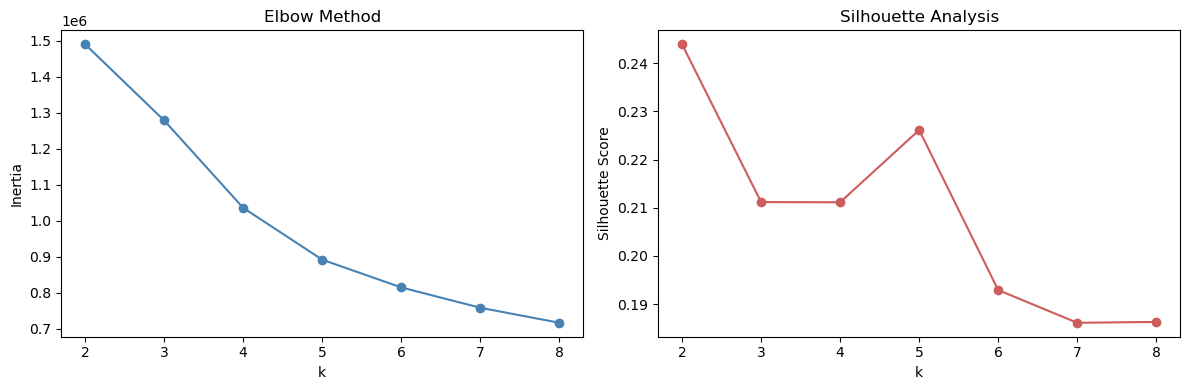

In [57]:
inertias = []
silhouettes = []
K_range = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil = silhouette_score(
        X_scaled,
        labels,
        sample_size=3000,
        random_state=42
    )
    silhouettes.append(sil)
    
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(K_range, inertias, 'o-', color='steelblue')
ax1.set_xlabel('k'); ax1.set_ylabel('Inertia'); ax1.set_title('Elbow Method')
ax2.plot(K_range, silhouettes, 'o-', color='indianred')
ax2.set_xlabel('k'); ax2.set_ylabel('Silhouette Score'); ax2.set_title('Silhouette Analysis')
plt.tight_layout()
plt.show()

## 3. Fit Final Model and Profile Clusters

In [58]:
optimal_k = 5
km = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df["customer_segment"] = km.fit_predict(X_scaled)

df["customer_segment"].value_counts().sort_index()

customer_segment
0     68962
1     99271
2         1
3    102608
4     36669
Name: count, dtype: int64

In [59]:
cluster_profile = df.groupby("customer_segment")[cluster_features + ["TARGET"]].mean().rename(columns={"TARGET": "DEFAULT_RATE"})
cluster_profile

,AMT_INCOME_TOTAL,AMT_CREDIT,CREDIT_INCOME_RATIO,AGE,EXT_SOURCE_MEAN,BUREAU_RECORD_COUNT,DEFAULT_RATE
customer_segment,,,,,,,
0,1.771126e+05,1.135028e+06,7.455130,45.851714,0.545215,4.816864,0.058017
1,1.609187e+05,4.144498e+05,2.815830,32.882440,0.439226,3.992579,0.128769
2,1.170000e+08,5.624910e+05,0.004808,34.561644,0.239838,4.000000,1.000000
3,1.581663e+05,4.231013e+05,2.959557,52.826156,0.567656,4.139504,0.047404
4,2.010552e+05,5.829518e+05,3.263552,45.389379,0.486651,13.590776,0.086613


In [60]:
segment_names = {
    0: "Segment 0 - Standard Borrowers",
    1: "Segment 1 - Higher Risk Borrowers",
    2: "Segment 2 - Strong Credit Profile",
    3: "Segment 3 - Limited Credit History"
}

df["customer_segment_name"] = df["customer_segment"].map(segment_names)

df.head()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_EDUCATION_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,...,WALLSMATERIAL_MODE_Monolithic,WALLSMATERIAL_MODE_Others,WALLSMATERIAL_MODE_Panel,"WALLSMATERIAL_MODE_Stone, brick",WALLSMATERIAL_MODE_Wooden,EMERGENCYSTATE_MODE_Yes,ORGANIZATION_TYPE_freq,OCCUPATION_TYPE_freq,customer_segment,customer_segment_name
0,100002,1,0,202500.0,406597.5,24700.5,351000.0,1,0.018801,-9461,...,False,False,False,True,False,False,0.221104,0.492916,1,Segment 1 - Higher Risk Borrowers
1,100003,0,0,270000.0,1293502.5,35698.5,1129500.0,3,0.003541,-16765,...,False,False,False,False,False,False,0.028919,0.089655,0,Segment 0 - Standard Borrowers
2,100004,0,0,67500.0,135000.0,6750.0,135000.0,1,0.010032,-19046,...,False,False,True,False,False,False,0.033833,0.492916,3,Segment 3 - Limited Credit History
3,100006,0,0,135000.0,312682.5,29686.5,297000.0,1,0.008019,-19005,...,False,False,True,False,False,False,0.221104,0.492916,3,Segment 3 - Limited Credit History
4,100007,0,0,121500.0,513000.0,21865.5,513000.0,1,0.028663,-19932,...,False,False,True,False,False,False,0.000276,0.089655,3,Segment 3 - Limited Credit History


In [63]:
df.groupby("customer_segment_name")["TARGET"].mean()

customer_segment_name
Segment 0 - Standard Borrowers        0.058017
Segment 1 - Higher Risk Borrowers     0.128769
Segment 2 - Strong Credit Profile     1.000000
Segment 3 - Limited Credit History    0.047404
Name: TARGET, dtype: float64

## 4. Test Whether Customer Segment Improves Model

In [65]:
X_base = df.drop(columns=["TARGET","customer_segment","customer_segment_name"])

y = df["TARGET"]

cat_cols = X_base.select_dtypes(exclude=np.number).columns.tolist()

X_base = pd.get_dummies(
    X_base,
    columns=cat_cols,
    drop_first=True
)

bool_cols = X_base.select_dtypes(include="bool").columns

X_base[bool_cols] = X_base[bool_cols].astype(int)

In [66]:
segment_dummies = pd.get_dummies(
    df["customer_segment"],
    prefix="segment",
    drop_first=True,
    dtype=int
)

X_seg = pd.concat([X_base, segment_dummies],axis=1)

In [67]:
X_train_base, X_test_base, y_train, y_test = train_test_split(
    X_base,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

X_train_seg = X_seg.loc[X_train_base.index]
X_test_seg = X_seg.loc[X_test_base.index]

In [68]:
best_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", GradientBoostingClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        random_state=42
    ))
])

# Without segment
best_model.fit(X_train_base, y_train)
base_auroc = roc_auc_score(
    y_test,
    best_model.predict_proba(X_test_base)[:, 1]
)

# With segment
best_model.fit(X_train_seg, y_train)
seg_auroc = roc_auc_score(
    y_test,
    best_model.predict_proba(X_test_seg)[:, 1]
)

print(f"AUROC without segment: {base_auroc:.4f}")
print(f"AUROC with segment: {seg_auroc:.4f}")
print(f"Improvement: {seg_auroc - base_auroc:.4f}")

AUROC without segment: 0.7681
AUROC with segment: 0.7683
Improvement: 0.0002
